# Visualization & Exploratory Data Analysis

**Objective:** Perform a complete EDA using the cleaned sales dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df = pd.DataFrame({
    "order_id": range(1001, 1021),
    "date": pd.date_range("2026-01-01", periods=20, freq="3D"),
    "region": np.random.choice(["Karachi", "Lahore", "Islamabad"], 20),
    "product": np.random.choice(["Laptop", "Phone", "Tablet", "Headphones"], 20),
    "quantity": np.random.randint(1, 7, 20),
    "unit_price": np.random.choice([8000, 45000, 65000, 120000], 20),
    "rating": np.round(np.random.uniform(3.5, 5.0, 20), 1)
})
df["revenue"] = df["quantity"] * df["unit_price"]
df.head()

,order_id,date,region,product,quantity,unit_price,rating,revenue
0,1001,2026-01-01,Islamabad,Headphones,6,45000,4.1,270000
1,1002,2026-01-04,Karachi,Headphones,6,8000,3.8,48000
2,1003,2026-01-07,Islamabad,Laptop,6,45000,4.4,270000
3,1004,2026-01-10,Islamabad,Laptop,3,120000,3.5,360000
4,1005,2026-01-13,Karachi,Headphones,4,120000,4.8,480000


## 1. Basic inspection

In [2]:
display(df.describe())
print("Missing values:")
display(df.isna().sum())

,order_id,date,quantity,unit_price,rating,revenue
count,20.00000,20,20.000000,20.000000,20.000000,20.000000
mean,1010.50000,2026-01-29 12:00:00,3.450000,73450.000000,4.365000,244250.000000
min,1001.00000,2026-01-01 00:00:00,1.000000,8000.000000,3.500000,8000.000000
25%,1005.75000,2026-01-15 06:00:00,2.000000,45000.000000,4.100000,106250.000000
50%,1010.50000,2026-01-29 12:00:00,3.500000,65000.000000,4.400000,240000.000000
75%,1015.25000,2026-02-12 18:00:00,5.000000,120000.000000,4.650000,292500.000000
max,1020.00000,2026-02-27 00:00:00,6.000000,120000.000000,4.900000,600000.000000
std,5.91608,NaN,1.820208,42623.782588,0.393734,182043.625483


Missing values:


order_id      0
date          0
region        0
product       0
quantity      0
unit_price    0
rating        0
revenue       0
dtype: int64

## 2. Revenue distribution

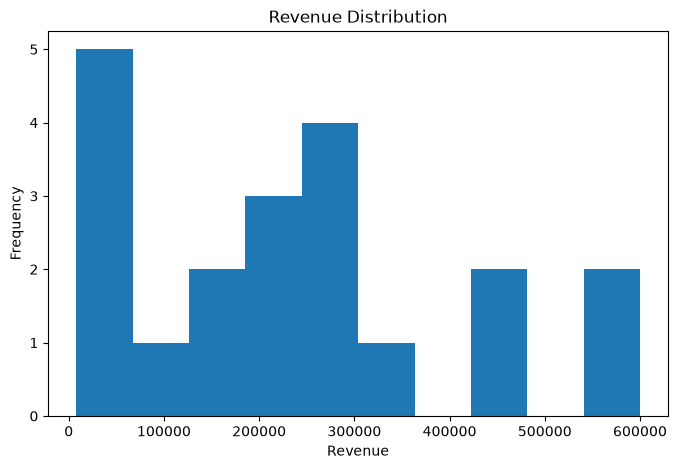

In [3]:
plt.figure(figsize=(8, 5))
plt.hist(df["revenue"], bins=10)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

## 3. Quantity distribution

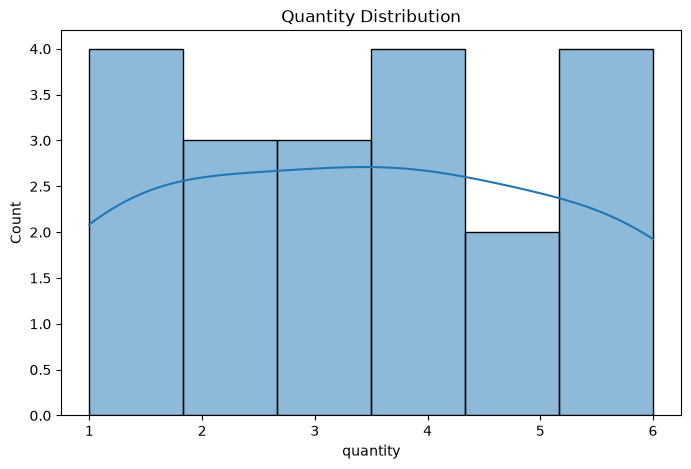

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="quantity", bins=6, kde=True)
plt.title("Quantity Distribution")
plt.show()

## 4. Revenue by product

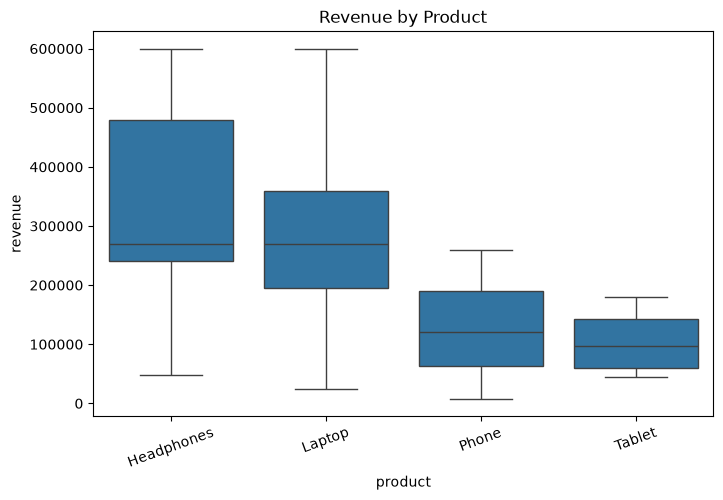

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="product", y="revenue")
plt.xticks(rotation=20)
plt.title("Revenue by Product")
plt.show()

## 5. Regional revenue

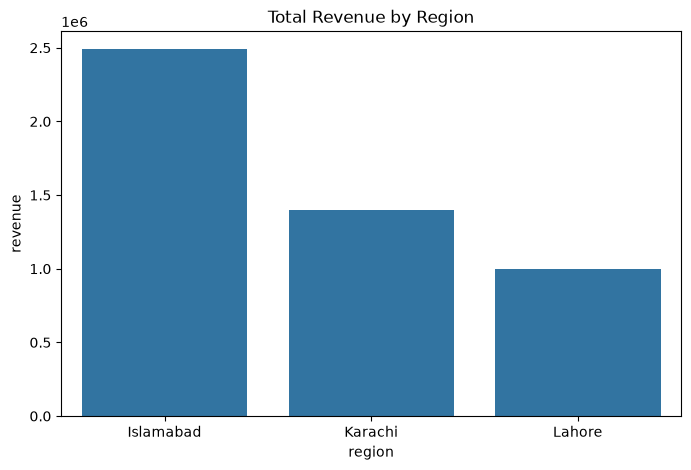

In [6]:
region_revenue = df.groupby("region", as_index=False)["revenue"].sum()

plt.figure(figsize=(8, 5))
sns.barplot(data=region_revenue, x="region", y="revenue")
plt.title("Total Revenue by Region")
plt.show()

## 6. Quantity vs revenue

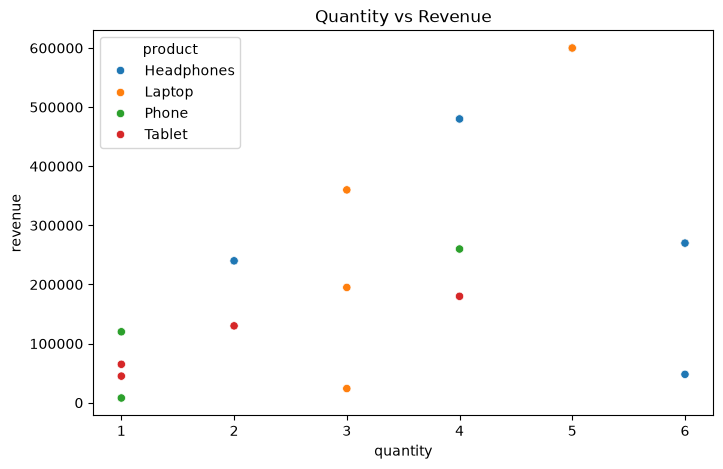

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="quantity", y="revenue", hue="product")
plt.title("Quantity vs Revenue")
plt.show()

## 7. Correlation heatmap

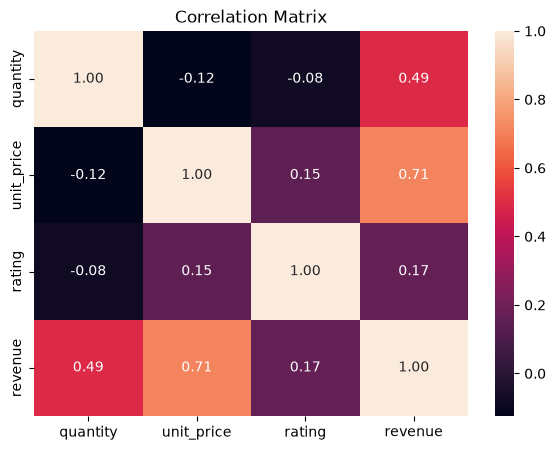

In [8]:
numeric = df[["quantity", "unit_price", "rating", "revenue"]]

plt.figure(figsize=(7, 5))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 8. EDA findings

In [9]:
findings = [
    "Revenue is strongly influenced by unit price and quantity.",
    "Higher-priced products can generate substantially more revenue per order.",
    "The revenue distribution is right-skewed because premium products create high-value orders.",
    "Quantity has a positive relationship with revenue.",
    "Regional revenue differs according to the mix and volume of products sold.",
    "Customer ratings show less variation than revenue.",
    "Box plots are useful for spotting high-value orders and potential outliers.",
    "Correlation measures linear relationships but does not imply causation."
]
for i, finding in enumerate(findings, 1):
    print(f"{i}. {finding}")

1. Revenue is strongly influenced by unit price and quantity.
2. Higher-priced products can generate substantially more revenue per order.
3. The revenue distribution is right-skewed because premium products create high-value orders.
4. Quantity has a positive relationship with revenue.
5. Regional revenue differs according to the mix and volume of products sold.
6. Customer ratings show less variation than revenue.
7. Box plots are useful for spotting high-value orders and potential outliers.
8. Correlation measures linear relationships but does not imply causation.


## Conclusion

The EDA examined distributions, outliers, categorical comparisons, relationships and correlations. Visualization makes patterns easier to identify and provides evidence for subsequent modeling or business decisions.